## Calibration Curve

### Calibration Curve (Binary Classification)

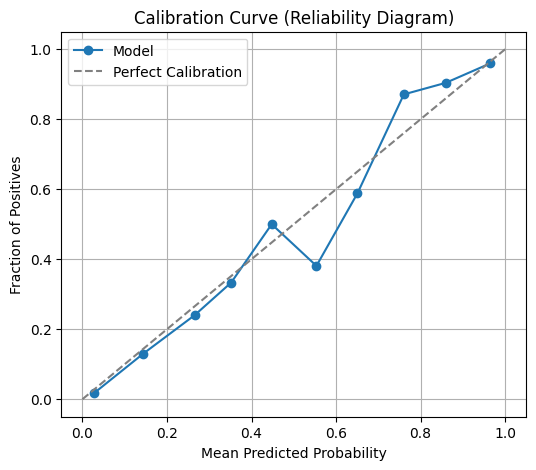

In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import calibration_curve

# Data
X, y = make_classification(n_samples=2000, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

# Model
model = LogisticRegression()
model.fit(X_train, y_train)

# Predicted probabilities
y_prob = model.predict_proba(X_test)[:, 1]

# Calibration curve
prob_true, prob_pred = calibration_curve(
    y_test, y_prob, n_bins=10, strategy="uniform"
)

# Plot
plt.figure(figsize=(6, 5))
plt.plot(prob_pred, prob_true, marker="o", label="Model")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfect Calibration")

plt.xlabel("Mean Predicted Probability")
plt.ylabel("Fraction of Positives")
plt.title("Calibration Curve (Reliability Diagram)")
plt.legend()
plt.grid()
plt.show()


### Calibration Curve with Multiple Models

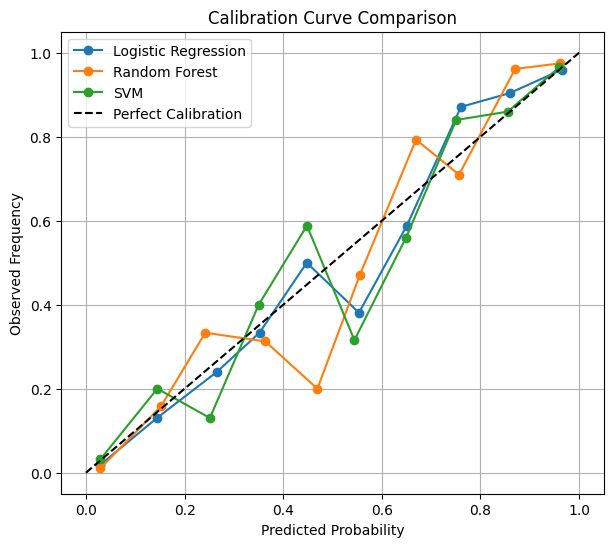

In [2]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

models = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(probability=True)
}

plt.figure(figsize=(7, 6))

for name, model in models.items():
    model.fit(X_train, y_train)
    y_prob = model.predict_proba(X_test)[:, 1]

    prob_true, prob_pred = calibration_curve(y_test, y_prob, n_bins=10)
    plt.plot(prob_pred, prob_true, marker="o", label=name)

plt.plot([0, 1], [0, 1], "k--", label="Perfect Calibration")
plt.xlabel("Predicted Probability")
plt.ylabel("Observed Frequency")
plt.title("Calibration Curve Comparison")
plt.legend()
plt.grid()
plt.show()


### Calibration Curve for Imbalanced Data

In [3]:
prob_true, prob_pred = calibration_curve(
    y_test, y_prob, n_bins=10, strategy="quantile"
)


### Calibration with Post-Processing (Platt & Isotonic)

In [6]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import RandomForestClassifier

platt = CalibratedClassifierCV(
    estimator=RandomForestClassifier(),
    method="sigmoid",
    cv=5
)

platt.fit(X_train, y_train)


# Isotonic regression
isotonic = CalibratedClassifierCV(
    estimator=RandomForestClassifier(),
    method="isotonic",
    cv=5
)

isotonic.fit(X_train, y_train)



,estimator,RandomForestClassifier()
,method,'isotonic'
,cv,5
,n_jobs,None
,ensemble,'auto'
,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0


### Brier Score (Calibration Metric)

In [5]:
from sklearn.metrics import brier_score_loss

brier = brier_score_loss(y_test, y_prob)
print("Brier Score:", brier)


Brier Score: 0.08245848945901317
